<a href="https://colab.research.google.com/github/rajanaids-hub/Image-and-Video-Analytics/blob/main/CV_Unit1_Complete_HandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Computer Vision – Unit 1: Complete Hands-On Tutorial
### Best Teaching Notebook (2026 Edition)

---
**Syllabus Coverage:**
1. Digital Image Representation – Sampling & Quantization
2. Types of Images
3. Basic Relations between Pixels – Neighbors – Connectivity – Distance Measures
4. Introduction to Digital Video – Sampled Video – Video Transmission
5. Gray-Level Processing: Image Histogram
6. Arithmetic Operations between Images
7. Geometric Image Operations
8. Binary Image Processing
9. Binary Image Morphology

---
> 💡 **Each section:** Concept → Visual Explanation → Code with Comments → Student Exercise


## 📦 Step 0: Install & Import All Required Packages

In [ ]:
# ─── Install all required libraries (run this cell first) ───────────────────
# numpy      : numerical operations on image arrays
# matplotlib : plotting and displaying images
# opencv-python (cv2) : main computer vision library
# scikit-image (skimage) : additional image processing algorithms
# Pillow (PIL) : image file reading/writing
# scipy      : morphological operations and filters
# imageio    : reading/writing image/video files

import subprocess, sys
packages = ["numpy", "matplotlib", "opencv-python", "scikit-image",
            "Pillow", "scipy", "imageio"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ All packages installed successfully!")

In [ ]:
# ─── Import all libraries we will use throughout this notebook ──────────────
import numpy as np                          # array / matrix math
import matplotlib.pyplot as plt             # plotting & display
import matplotlib.patches as patches        # drawing shapes on plots
import cv2                                  # OpenCV – core vision library
from skimage import data, color, filters, morphology, measure
from skimage.transform import resize, rotate, rescale, AffineTransform, warp
from skimage.draw import disk, rectangle_perimeter
from scipy import ndimage                   # neighbor/morphology helpers
from PIL import Image                       # Pillow image I/O
import imageio                              # video / GIF writing
import warnings
warnings.filterwarnings('ignore')           # suppress minor warnings

# Global plot style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

print("✅ All imports successful!")
print(f"   numpy  : {np.__version__}")
print(f"   OpenCV : {cv2.__version__}")

---
# 🟦 SECTION 1 – Digital Image Representation, Sampling & Quantization

### 📖 Theory in 3 Lines
- An **image** is a 2-D function `f(x, y)` where x,y are spatial coords and f is intensity.
- **Sampling** = deciding *how many pixels* (spatial resolution).
- **Quantization** = deciding *how many grey levels* (intensity resolution, e.g. 2-bit = 4 levels, 8-bit = 256 levels).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1A – SAMPLING DEMONSTRATION
#      We take a high-resolution image and down-sample it to show the effect
# ════════════════════════════════════════════════════════════════════════════

# Load a built-in grayscale test image (camera-man, 512×512)
original = data.camera()          # numpy array, dtype=uint8, values 0-255
print(f"Original image shape : {original.shape}")
print(f"Pixel value range    : {original.min()} – {original.max()}")
print(f"Data type            : {original.dtype}")

# Different spatial sampling rates (number of pixels)
sampling_levels = [512, 256, 128, 64, 32, 16]

fig, axes = plt.subplots(1, len(sampling_levels), figsize=(18, 3))
fig.suptitle("SAMPLING EFFECT – fewer pixels = more blocky", fontsize=13, fontweight='bold')

for ax, N in zip(axes, sampling_levels):
    # Resize to N×N (down-sample), then scale back to 512 for display
    small  = resize(original, (N, N), anti_aliasing=False, preserve_range=True)
    big    = resize(small, (512, 512), order=0, preserve_range=True)  # order=0 = nearest neighbour
    ax.imshow(big.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{N}×{N}\n({N*N} pixels)", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("👆 Notice: as pixels decrease, image becomes coarser (pixelated)")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1B – QUANTIZATION DEMONSTRATION
#      Keep the same number of pixels, but reduce the number of grey levels
# ════════════════════════════════════════════════════════════════════════════

# Number of bits → number of intensity levels (2^bits)
bit_depths = [8, 6, 4, 3, 2, 1]   # 8-bit = 256 levels … 1-bit = 2 levels

fig, axes = plt.subplots(1, len(bit_depths), figsize=(18, 3))
fig.suptitle("QUANTIZATION EFFECT – fewer bits = fewer grey shades", fontsize=13, fontweight='bold')

for ax, bits in zip(axes, bit_depths):
    levels      = 2 ** bits           # e.g. 4 bits → 16 levels
    # Scale 0-255 → 0-(levels-1) → scale back to 0-255 for display
    quantized   = np.floor(original / 256 * levels) / levels * 255
    ax.imshow(quantized.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{bits}-bit\n({levels} levels)", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("👆 Notice: as bits decrease, image develops 'false contours' (banding)")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1C – IMAGE AS A MATRIX (Conceptual Zoom)
#      Show students the actual pixel numbers inside a small patch
# ════════════════════════════════════════════════════════════════════════════

# Extract a tiny 8×8 patch from the top-left corner
patch = original[0:8, 0:8]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: show the patch magnified
ax1.imshow(patch, cmap='gray', vmin=0, vmax=255)
ax1.set_title("8×8 pixel patch (magnified)")
ax1.axis('off')

# Right: show the actual numbers as a heatmap with values printed
ax2.imshow(patch, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        # Print each pixel value on top of its cell
        ax2.text(j, i, str(patch[i, j]), ha='center', va='center',
                 color='red', fontsize=8, fontweight='bold')
ax2.set_title("Same patch with pixel VALUES shown")
ax2.axis('off')

plt.suptitle("📐 An image is just a 2-D array of numbers!", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🟩 SECTION 2 – Types of Images

| Type | Channels | Bits/pixel | Description |
|------|----------|------------|-------------|
| Binary | 1 | 1 | Only 0 (black) or 1 (white) |
| Grayscale | 1 | 8 | 256 shades of grey |
| RGB Color | 3 | 24 | Red, Green, Blue channels |
| HSV | 3 | 24 | Hue, Saturation, Value |
| Multispectral | >3 | varies | Medical / satellite imagery |

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 2 – TYPES OF IMAGES
# ════════════════════════════════════════════════════════════════════════════

# Load a built-in color image (astronaut)
color_img = data.astronaut()                    # shape (512,512,3)  RGB uint8

# Convert to grayscale
gray_img  = color.rgb2gray(color_img)           # values 0.0 – 1.0 float64

# Convert to binary (threshold at mean intensity)
threshold  = gray_img.mean()                    # pick midpoint as threshold
binary_img = gray_img > threshold               # True/False array → white/black

# Convert to HSV colour space
hsv_img   = color.rgb2hsv(color_img)            # shape (512,512,3)  H,S,V

# ── Plot all types side by side ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("TYPES OF IMAGES", fontsize=14, fontweight='bold')

# Row 0 – images
axes[0,0].imshow(binary_img, cmap='gray');  axes[0,0].set_title("Binary (1-bit)")
axes[0,1].imshow(gray_img,   cmap='gray');  axes[0,1].set_title("Grayscale (8-bit)")
axes[0,2].imshow(color_img);                axes[0,2].set_title("RGB Color (24-bit)")
axes[0,3].imshow(hsv_img);                  axes[0,3].set_title("HSV Color Space")

# Row 1 – show individual channels
axes[1,0].imshow(color_img[:,:,0], cmap='Reds');   axes[1,0].set_title("Red channel")
axes[1,1].imshow(color_img[:,:,1], cmap='Greens'); axes[1,1].set_title("Green channel")
axes[1,2].imshow(color_img[:,:,2], cmap='Blues');  axes[1,2].set_title("Blue channel")
axes[1,3].imshow(hsv_img[:,:,0],   cmap='hsv');    axes[1,3].set_title("Hue channel")

for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.show()

# Print shape info for each type
print(f"Binary  shape: {binary_img.shape}, dtype: {binary_img.dtype}")
print(f"Gray    shape: {gray_img.shape},   dtype: {gray_img.dtype}")
print(f"Color   shape: {color_img.shape},  dtype: {color_img.dtype}")
print(f"HSV     shape: {hsv_img.shape},    dtype: {hsv_img.dtype}")

---
# 🟨 SECTION 3 – Pixel Relations: Neighbors, Connectivity & Distance Measures

### 📖 Key Concepts
- **4-Neighbors** of pixel (x,y): `(x-1,y)`, `(x+1,y)`, `(x,y-1)`, `(x,y+1)`
- **8-Neighbors** (diagonal included): all 8 surrounding pixels
- **Connectivity**: two pixels are *connected* if they are neighbors AND satisfy some intensity criterion
- **Distance Measures**: Euclidean, City-block (Manhattan), Chessboard (Chebyshev)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3A – VISUALIZE 4-NEIGHBORS AND 8-NEIGHBORS
# ════════════════════════════════════════════════════════════════════════════

def draw_neighborhood(ax, title, highlight_cells):
    """Draw a 5×5 grid and highlight specific cells."""
    grid = np.zeros((5, 5))            # 5×5 empty grid
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Draw grid lines
    for x in range(6): ax.axvline(x-0.5, color='black', linewidth=0.8)
    for y in range(6): ax.axhline(y-0.5, color='black', linewidth=0.8)

    # Centre pixel (2,2) – always shown in blue
    ax.add_patch(patches.Rectangle((1.5, 1.5), 1, 1, color='royalblue', zorder=2))
    ax.text(2, 2, 'P', ha='center', va='center', fontsize=12,
            fontweight='bold', color='white', zorder=3)

    # Highlighted neighbors – shown in orange
    for (r, c) in highlight_cells:
        ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1,
                                        color='darkorange', alpha=0.7, zorder=2))
        ax.text(c, r, 'N', ha='center', va='center',
                fontsize=11, color='white', zorder=3)

    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.invert_yaxis()

# Define 4-neighbors of centre pixel (2,2)
four_neighbors  = [(1,2), (3,2), (2,1), (2,3)]

# Define 8-neighbors (4-neighbors + diagonals)
eight_neighbors = [(1,1), (1,2), (1,3),
                   (2,1),        (2,3),
                   (3,1), (3,2), (3,3)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
draw_neighborhood(ax1, "4-Neighbors  N4(P)", four_neighbors)
draw_neighborhood(ax2, "8-Neighbors  N8(P)", eight_neighbors)
plt.suptitle("Pixel Neighborhood", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3B – CONNECTIVITY (Connected Components Labeling)
#      Each separate blob of white pixels gets a unique colour label
# ════════════════════════════════════════════════════════════════════════════

# Manually create a small binary image with 3 separate blobs
# 0 = background (black), 1 = foreground (white)
binary_example = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,0,0,0,1,1,1,0,0,0],
    [0,1,1,1,0,0,1,1,1,0,0,0],
    [0,0,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,1,1,1],
    [0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0],
], dtype=np.uint8)

# Label connected components using 8-connectivity
labeled_8, n_components_8 = measure.label(
    binary_example, connectivity=2, return_num=True)  # connectivity=2 → 8-neighbours

# Label with 4-connectivity for comparison
labeled_4, n_components_4 = measure.label(
    binary_example, connectivity=1, return_num=True)  # connectivity=1 → 4-neighbours

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(binary_example, cmap='gray')
axes[0].set_title("Original Binary Image")

axes[1].imshow(labeled_4, cmap='tab10')
axes[1].set_title(f"4-Connectivity: {n_components_4} components")

axes[2].imshow(labeled_8, cmap='tab10')
axes[2].set_title(f"8-Connectivity: {n_components_8} components")

for ax in axes:
    ax.axis('off')

plt.suptitle("CONNECTIVITY – Different connectivity rules can give different counts",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3C – DISTANCE MEASURES
#      Euclidean, City-block (Manhattan), Chessboard (Chebyshev)
# ════════════════════════════════════════════════════════════════════════════

# Reference point (centre of a 11×11 grid)
centre = np.array([5, 5])
SIZE   = 11

# Build co-ordinate grids
rows, cols = np.indices((SIZE, SIZE))  # row[i,j]=i, col[i,j]=j

# ── Euclidean distance  D_e(p,q) = sqrt((x1-x2)²+(y1-y2)²) ──────────────
euclidean = np.sqrt((rows - centre[0])**2 + (cols - centre[1])**2)

# ── City-block (Manhattan)  D_4(p,q) = |x1-x2| + |y1-y2| ───────────────
cityblock = np.abs(rows - centre[0]) + np.abs(cols - centre[1])

# ── Chessboard (Chebyshev)  D_8(p,q) = max(|x1-x2|, |y1-y2|) ───────────
chessboard = np.maximum(np.abs(rows - centre[0]), np.abs(cols - centre[1]))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles     = ["Euclidean Distance", "City-block (Manhattan) D4", "Chessboard (Chebyshev) D8"]
maps       = [euclidean, cityblock, chessboard]

for ax, title, dmap in zip(axes, titles, maps):
    im = ax.imshow(dmap, cmap='YlOrRd', interpolation='nearest')
    # Annotate each cell with its distance value
    for i in range(SIZE):
        for j in range(SIZE):
            ax.text(j, i, f"{dmap[i,j]:.1f}", ha='center', va='center',
                    fontsize=7, color='navy')
    # Mark the centre point
    ax.add_patch(patches.Circle((centre[1], centre[0]), 0.4,
                                 color='blue', zorder=5))
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("DISTANCE MEASURES from centre pixel (blue dot)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Example calculation
p, q = np.array([5, 5]), np.array([2, 8])
print(f"Distance from {p} to {q}:")
print(f"  Euclidean  = {np.sqrt(np.sum((p-q)**2)):.3f}")
print(f"  City-block = {np.sum(np.abs(p-q))}")
print(f"  Chessboard = {np.max(np.abs(p-q))}")

---
# 🟪 SECTION 4 – Introduction to Digital Video: Sampled Video & Video Transmission

### 📖 Key Concepts
- A **video** is a sequence of images (frames) played at a frame rate (fps).
- **Temporal sampling** = frame rate (e.g., 24/30/60 fps)
- **Spatial sampling** = resolution per frame (e.g., 1920×1080)
- **Video Transmission Bandwidth** = width × height × fps × bits_per_pixel

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 4A – SIMULATE VIDEO AS A SEQUENCE OF FRAMES
#      Create a simple animated ball bouncing to simulate video frames
# ════════════════════════════════════════════════════════════════════════════

# Video parameters
FRAME_W, FRAME_H = 120, 80    # frame dimensions (pixels)
N_FRAMES          = 12        # number of frames in our simulated video
BALL_RADIUS       = 8         # ball radius in pixels

frames = []   # list to collect all frames

for t in range(N_FRAMES):
    # Create a grey background frame
    frame = np.full((FRAME_H, FRAME_W, 3), 220, dtype=np.uint8)

    # Ball position: moves horizontally; bounces up-down sinusoidally
    cx = int(BALL_RADIUS + t * (FRAME_W - 2*BALL_RADIUS) / (N_FRAMES - 1))
    cy = int(FRAME_H//2 + (FRAME_H//3) * np.sin(t * np.pi / (N_FRAMES/2)))

    # Draw filled circle (ball) using skimage disk mask
    rr, cc = disk((cy, cx), BALL_RADIUS, shape=frame.shape)
    frame[rr, cc] = [220, 60, 60]    # red ball

    # Draw a simple "floor" line
    frame[FRAME_H - 5 : FRAME_H - 3, :] = [80, 80, 80]

    frames.append(frame)

# Display all frames in a strip
fig, axes = plt.subplots(2, 6, figsize=(18, 5))
fig.suptitle("VIDEO = Sequence of Frames (simulated bouncing ball)",
             fontsize=12, fontweight='bold')

for idx, (ax, frame) in enumerate(zip(axes.ravel(), frames)):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Total frames created : {len(frames)}")
print(f"Each frame size      : {FRAME_H}×{FRAME_W}×3 = {FRAME_H*FRAME_W*3:,} bytes")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 4B – SAVE AS ANIMATED GIF (simulated video file)
# ════════════════════════════════════════════════════════════════════════════

gif_path = "simulated_video.gif"
# duration=100 means each frame displayed for 100 ms → 10 fps
imageio.mimsave(gif_path, frames, duration=100, loop=0)
print(f"✅ Video saved as GIF → {gif_path}")

# Display the GIF inline using IPython
from IPython.display import Image as IPImage, display
display(IPImage(filename=gif_path))

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 4C – VIDEO BANDWIDTH CALCULATION
#      Formula: BW = W × H × fps × bits_per_pixel  (bits/sec)
# ════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("VIDEO BANDWIDTH (Uncompressed Raw Data)")
print("=" * 60)
print(f"{'Format':<20} {'W×H':>10} {'FPS':>5} {'BPP':>5} {'Bandwidth':>15}")
print("-" * 60)

# (name, width, height, fps, bits_per_pixel)
formats = [
    ("QVGA (old phone)",  320,  240, 15, 24),
    ("SD (DVD)",          720,  480, 25, 24),
    ("HD 720p",          1280,  720, 30, 24),
    ("Full HD 1080p",    1920, 1080, 30, 24),
    ("4K UHD",           3840, 2160, 60, 24),
]

for name, w, h, fps, bpp in formats:
    bw_bps  = w * h * fps * bpp             # bits per second
    bw_mbps = bw_bps / 1e6                  # megabits per second
    print(f"{name:<20} {str(w)+'×'+str(h):>10} {fps:>5} {bpp:>5} {bw_mbps:>12.1f} Mbps")

print("="*60)
print("\n💡 This is WHY video compression (H.264, H.265, AV1) is essential!")
print("   H.264 typically achieves 100:1 to 1000:1 compression ratio.")

---
# 🟧 SECTION 5 – Gray-Level Processing: Image Histogram

### 📖 Key Concepts
- **Histogram** = bar chart of how many pixels have each intensity (0–255)
- **Histogram Equalization** = spreads the distribution → increases contrast
- **Histogram Specification (Matching)** = map histogram to any target shape

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 5A – PLOT IMAGE HISTOGRAM
# ════════════════════════════════════════════════════════════════════════════

# Use the cameraman image
img_gray = data.camera()                  # 512×512 uint8 grayscale

# Compute histogram manually using numpy
hist, bin_edges = np.histogram(img_gray.ravel(),   # flatten to 1-D
                                bins=256,
                                range=(0, 256))

# CDF (Cumulative Distribution Function) – used in equalization
cdf = hist.cumsum()                         # running total of counts
cdf_norm = cdf * hist.max() / cdf.max()     # normalize for overlay plotting

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("IMAGE HISTOGRAM ANALYSIS", fontsize=13, fontweight='bold')

# Image
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Original Image"); axes[0].axis('off')

# Histogram
axes[1].bar(bin_edges[:-1], hist, width=1, color='steelblue', alpha=0.8)
axes[1].set_title("Histogram (frequency of each grey level)")
axes[1].set_xlabel("Grey Level (0=black, 255=white)")
axes[1].set_ylabel("Number of Pixels")
axes[1].set_xlim([0, 255])

# Histogram + CDF
axes[2].bar(bin_edges[:-1], hist, width=1, color='steelblue', alpha=0.6, label='PDF')
axes[2].plot(cdf_norm, color='red', linewidth=2, label='CDF')
axes[2].set_title("Histogram + CDF")
axes[2].set_xlabel("Grey Level")
axes[2].legend()
axes[2].set_xlim([0, 255])

plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 5B – HISTOGRAM EQUALIZATION (step-by-step from scratch)
#      Algorithm:
#      1. Compute histogram  h[r]  for each grey level r
#      2. Compute CDF  →  cdf[r] = Σ h[0..r]
#      3. Normalize:  T(r) = round( (cdf[r] - cdf_min) / (N - cdf_min) * 255 )
#      4. Map each pixel using the lookup table T
# ════════════════════════════════════════════════════════════════════════════

# Create a low-contrast (dark) test image
dark_img = (img_gray * 0.4).astype(np.uint8)   # darken by 60%

def histogram_equalization(image):
    """Perform histogram equalization from scratch (no OpenCV)."""
    # Step 1: compute histogram
    hist, _ = np.histogram(image.ravel(), bins=256, range=(0, 256))

    # Step 2: compute CDF
    cdf = hist.cumsum()

    # Step 3: compute look-up table (LUT)
    cdf_min = cdf[cdf > 0].min()           # ignore zero bins
    N       = image.size                    # total number of pixels
    lut     = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)

    # Step 4: apply LUT (map each pixel through the table)
    equalized = lut[image]                  # fancy indexing
    return equalized, lut

eq_img, lut = histogram_equalization(dark_img)

# ── Plot comparison ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("HISTOGRAM EQUALIZATION", fontsize=13, fontweight='bold')

images  = [dark_img, eq_img]
titles  = ["Dark (low contrast)", "After Equalization"]
colours = ['royalblue', 'darkorange']

for col, (img, title, col_c) in enumerate(zip(images, titles, colours)):
    axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(title); axes[0, col].axis('off')

    h, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    axes[1, col].bar(range(256), h, width=1, color=col_c, alpha=0.8)
    axes[1, col].set_xlabel("Grey Level"); axes[1, col].set_ylabel("Count")
    axes[1, col].set_title(f"Histogram of {title}")
    axes[1, col].set_xlim([0, 255])

# Show the Look-Up Table (mapping)
axes[0, 2].plot(range(256), lut, color='green', linewidth=2)
axes[0, 2].set_title("Look-Up Table T(r)")
axes[0, 2].set_xlabel("Input grey level"); axes[0, 2].set_ylabel("Output grey level")
axes[0, 2].grid(True, alpha=0.4)

axes[1, 2].axis('off')   # leave blank

plt.tight_layout()
plt.show()
print("👆 Equalized histogram is much flatter → better contrast")

---
# 🟥 SECTION 6 – Arithmetic Operations between Images

| Operation | Formula | Use Case |
|-----------|---------|----------|
| Addition | `s = f + g` | Blending / superimposing |
| Subtraction | `s = f - g` | Change detection, background removal |
| Multiplication | `s = f × g` | Masking, sharpening |
| Division | `s = f / g` | Illumination correction |
| Averaging | `s = (f+g)/2` | Noise reduction |

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 6A – ARITHMETIC OPERATIONS
# ════════════════════════════════════════════════════════════════════════════

# We will work with float32 to avoid overflow/underflow
img_a = data.camera().astype(np.float32) / 255.0     # cameraman  [0,1]
img_b = data.coins().astype(np.float32)              # coins image, may be different size

# Resize img_b to match img_a
img_b = resize(img_b, img_a.shape, anti_aliasing=True).astype(np.float32)

# ── Arithmetic operations ─────────────────────────────────────────────────
# np.clip ensures result stays in [0,1]
add_img  = np.clip(img_a + img_b,        0, 1)  # Addition
sub_img  = np.clip(img_a - img_b + 0.5,  0, 1)  # Subtraction (offset by 0.5 to see both +/-)
mul_img  = np.clip(img_a * img_b * 2,    0, 1)  # Multiplication
blend_img= 0.6 * img_a + 0.4 * img_b            # Weighted blend (alpha blending)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("ARITHMETIC OPERATIONS BETWEEN IMAGES", fontsize=13, fontweight='bold')

ops    = [img_a, img_b, add_img, sub_img, mul_img, blend_img]
labels = ["Image A (Camera)", "Image B (Coins)",
          "A + B (Addition)", "A − B (Subtraction)",
          "A × B (Multiplication)", "0.6A + 0.4B (Blend)"]

for ax, img, label in zip(axes.ravel(), ops, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(label, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 6B – IMAGE SUBTRACTION FOR CHANGE DETECTION
#      Real-world use: motion detection in surveillance cameras
# ════════════════════════════════════════════════════════════════════════════

# Simulate frame 1 (background) and frame 2 (object moved)
frame1 = np.zeros((100, 100), dtype=np.float32)   # empty background
frame2 = np.zeros((100, 100), dtype=np.float32)   # background + object

# Add a stationary object in frame1 (white square at top-left)
frame1[20:50, 20:50] = 0.9

# Same object has MOVED in frame2 (now at bottom-right)
frame2[55:85, 55:85] = 0.9

# Difference reveals WHAT CHANGED between frames
diff = np.abs(frame2 - frame1)

# Threshold the diff to get a binary change mask
change_mask = diff > 0.3

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(frame1, cmap='gray'); axes[0].set_title("Frame 1 (before)")
axes[1].imshow(frame2, cmap='gray'); axes[1].set_title("Frame 2 (after)")
axes[2].imshow(diff,   cmap='hot');  axes[2].set_title("|Frame2 - Frame1| (difference)")
axes[3].imshow(change_mask, cmap='gray'); axes[3].set_title("Change Mask (thresholded)")

for ax in axes: ax.axis('off')
plt.suptitle("IMAGE SUBTRACTION → MOTION / CHANGE DETECTION",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🟤 SECTION 7 – Geometric Image Operations

### 📖 Operations
- **Translation** – shift the image
- **Rotation** – rotate around a point
- **Scaling** – zoom in/out
- **Shearing** – slant the image
- **Flipping** – mirror horizontally or vertically
- **Affine Transform** – general linear transform (combination of above)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 7A – GEOMETRIC TRANSFORMATIONS
# ════════════════════════════════════════════════════════════════════════════

orig = data.chelsea()                           # color cat image
orig_gray = color.rgb2gray(orig)               # work in grayscale

# ── 1. Translation ─────────────────────────────────────────────────────────
# Shift right by 80px and down by 50px using AffineTransform
shift_transform = AffineTransform(translation=(-80, -50))  # note: negative = shift right/down
translated = warp(orig_gray, shift_transform.inverse)

# ── 2. Rotation ────────────────────────────────────────────────────────────
rotated    = rotate(orig_gray, angle=30, resize=False)      # rotate 30 degrees

# ── 3. Scaling (zoom) ──────────────────────────────────────────────────────
scaled_up   = rescale(orig_gray, scale=1.5, anti_aliasing=True)
# Crop back to original size for comparison
h, w = orig_gray.shape
scaled_up_crop = scaled_up[:h, :w]

# ── 4. Horizontal flip ─────────────────────────────────────────────────────
flipped_h  = np.fliplr(orig_gray)                           # flip left-right

# ── 5. Vertical flip ───────────────────────────────────────────────────────
flipped_v  = np.flipud(orig_gray)                           # flip up-down

# ── 6. Affine shear ────────────────────────────────────────────────────────
shear_transform = AffineTransform(shear=0.3)
sheared = warp(orig_gray, shear_transform.inverse)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("GEOMETRIC TRANSFORMATIONS", fontsize=13, fontweight='bold')

images = [orig_gray, translated, rotated, scaled_up_crop,
          flipped_h, flipped_v, sheared]
labels = ["Original", "Translated (+80,+50)", "Rotated 30°", "Scaled ×1.5",
          "Flipped Horizontal", "Flipped Vertical", "Sheared"]

for ax, img, label in zip(axes.ravel(), images, labels):
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontweight='bold')
    ax.axis('off')

axes.ravel()[-1].axis('off')   # hide last empty subplot
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 7B – AFFINE TRANSFORMATION MATRIX (show the math)
# ════════════════════════════════════════════════════════════════════════════

import math

def make_rotation_matrix(angle_deg):
    """Build a 3×3 homogeneous rotation matrix."""
    theta = math.radians(angle_deg)
    M = np.array([
        [ math.cos(theta), -math.sin(theta), 0],
        [ math.sin(theta),  math.cos(theta), 0],
        [0,                 0,               1]
    ])
    return M

def make_translation_matrix(tx, ty):
    """Build a 3×3 homogeneous translation matrix."""
    M = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0,  1]
    ])
    return M

def make_scale_matrix(sx, sy):
    """Build a 3×3 homogeneous scale matrix."""
    M = np.array([
        [sx, 0,  0],
        [0,  sy, 0],
        [0,  0,  1]
    ])
    return M

# Example: rotate 45° then translate by (50, 30)
R = make_rotation_matrix(45)
T = make_translation_matrix(50, 30)
S = make_scale_matrix(2, 2)

# Combined transform = T × R   (apply R first, then T)
combined = T @ R

# Apply transform to a sample point P=(100, 100)
P = np.array([100, 100, 1])     # homogeneous coordinates
P_transformed = combined @ P

print("Rotation Matrix (45°):")
print(np.round(R, 3))
print("\nTranslation Matrix (+50,+30):")
print(T)
print("\nCombined (T × R):")
print(np.round(combined, 3))
print(f"\nPoint (100,100) → after transform → ({P_transformed[0]:.1f}, {P_transformed[1]:.1f})")

---
# ⚫ SECTION 8 – Binary Image Processing

### 📖 Key Concepts
- Binary images have only **0** (background) and **1** (foreground)
- **Thresholding** converts grayscale → binary
- **Otsu's method**: automatically finds the best threshold
- **Region properties**: area, perimeter, centroid, bounding box

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 8A – THRESHOLDING METHODS
#      Global, Otsu's, Adaptive
# ════════════════════════════════════════════════════════════════════════════

# Use coins image (nice separate objects on background)
coins = data.coins()                       # grayscale uint8

# Method 1: Global threshold (fixed value)
thresh_global  = 100                       # chosen manually
binary_global  = coins > thresh_global

# Method 2: Otsu's threshold (automatic – minimizes intra-class variance)
thresh_otsu    = filters.threshold_otsu(coins)
binary_otsu    = coins > thresh_otsu

# Method 3: Adaptive (local) threshold (handles uneven illumination)
thresh_adapt   = filters.threshold_local(coins, block_size=51, offset=10)
binary_adapt   = coins > thresh_adapt

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("THRESHOLDING METHODS", fontsize=13, fontweight='bold')

# Row 0 – images
axes[0,0].imshow(coins, cmap='gray');          axes[0,0].set_title("Original Grayscale")
axes[0,1].imshow(binary_global, cmap='gray');  axes[0,1].set_title(f"Global T={thresh_global}")
axes[0,2].imshow(binary_otsu,   cmap='gray');  axes[0,2].set_title(f"Otsu's T={thresh_otsu:.0f} (auto)")
axes[0,3].imshow(binary_adapt,  cmap='gray');  axes[0,3].set_title("Adaptive (local blocks)")

# Row 1 – histograms with threshold line
h, _ = np.histogram(coins.ravel(), 256, (0,256))
for col, (T, label) in enumerate([(thresh_global, 'T=100'),
                                    (thresh_otsu,   f"Otsu T={thresh_otsu:.0f}"),
                                    (thresh_adapt.mean(), 'Adaptive avg')]):
    axes[1, col+1].bar(range(256), h, width=1, color='steelblue', alpha=0.7)
    axes[1, col+1].axvline(T, color='red', linewidth=2, label=label)
    axes[1, col+1].legend()
    axes[1, col+1].set_xlabel("Intensity")
    axes[1, col+1].set_title(f"{label} on Histogram")

axes[1,0].axis('off')
for ax in axes[0]: ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Otsu's optimal threshold: {thresh_otsu:.0f}")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 8B – REGION PROPERTIES ON BINARY OBJECTS
#      After binarizing, analyze each connected region (blob)
# ════════════════════════════════════════════════════════════════════════════

# Use Otsu binary image of coins
labeled = measure.label(binary_otsu)              # label each blob
props   = measure.regionprops(labeled)            # compute properties

# Draw bounding boxes and centroids
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(coins, cmap='gray');  axes[0].set_title("Original")
axes[1].imshow(coins, cmap='gray');  axes[1].set_title("Detected Objects + Bounding Boxes")

print(f"{'Obj':<5} {'Area':>8} {'Centroid(r,c)':>20} {'BBox(r1,c1,r2,c2)':>30}")
print("-" * 65)

for idx, region in enumerate(props):
    # Only process regions larger than 200 pixels (ignore noise)
    if region.area < 200:
        continue

    # Bounding box: (min_row, min_col, max_row, max_col)
    r1, c1, r2, c2 = region.bbox
    cy, cx          = region.centroid

    # Draw rectangle on plot
    rect = patches.Rectangle((c1, r1), c2-c1, r2-r1,
                               linewidth=2, edgecolor='lime', facecolor='none')
    axes[1].add_patch(rect)

    # Mark centroid
    axes[1].plot(cx, cy, 'r+', markersize=10, markeredgewidth=2)

    print(f"{idx+1:<5} {region.area:>8} ({cy:7.1f},{cx:7.1f})    ({r1},{c1},{r2},{c2})")

axes[0].axis('off'); axes[1].axis('off')
plt.tight_layout()
plt.show()

---
# 🔷 SECTION 9 – Binary Image Morphology

### 📖 Key Concepts
Morphological operations use a **Structuring Element (SE)** (a small shape like a 3×3 cross or disc)
to probe the binary image.

| Operation | Effect | Use |
|-----------|--------|-----|
| **Erosion** | Shrinks objects, removes thin protrusions | Remove noise |
| **Dilation** | Grows objects, fills small holes | Connect gaps |
| **Opening** = Erosion then Dilation | Removes small bright blobs | Noise removal |
| **Closing** = Dilation then Erosion | Fills small dark holes | Hole filling |
| **Hit-or-Miss** | Find specific shape patterns | Pattern recognition |
| **Morphological Gradient** = Dilation − Erosion | Edge detection | Object edges |

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 9A – CREATE A TEST BINARY IMAGE WITH VARIOUS IMPERFECTIONS
# ════════════════════════════════════════════════════════════════════════════

# Create a 200×200 blank canvas
H, W = 200, 200
test_binary = np.zeros((H, W), dtype=np.uint8)

# Draw two solid rectangles
test_binary[30:80,  20:90]  = 1      # rectangle 1
test_binary[100:160, 110:180] = 1    # rectangle 2

# Draw a thin line (likely to be eroded away)
test_binary[20:22, 100:180]  = 1     # thin horizontal line

# Add small noise dots (will be removed by opening)
np.random.seed(42)
noise_points = np.random.randint(0, H*W, 150)
test_binary.ravel()[noise_points] = 1

# Punch small holes into rectangle 1 (will be filled by closing)
test_binary[45:50, 45:50] = 0
test_binary[55:60, 60:65] = 0

plt.figure(figsize=(5, 5))
plt.imshow(test_binary, cmap='gray')
plt.title("Test Binary Image\n(has noise dots + holes + thin line)", fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 9B – EROSION AND DILATION
# ════════════════════════════════════════════════════════════════════════════

# Define structuring elements of different shapes
se_square = morphology.square(5)           # 5×5 square SE
se_disk   = morphology.disk(4)             # circular SE radius=4
se_cross  = morphology.diamond(3)          # diamond/cross SE

# ── EROSION: shrink white regions ────────────────────────────────────────
# A pixel stays white ONLY if ALL pixels under the SE are white
eroded_sq  = morphology.binary_erosion(test_binary, se_square)
eroded_dk  = morphology.binary_erosion(test_binary, se_disk)

# ── DILATION: grow white regions ─────────────────────────────────────────
# A pixel becomes white if ANY pixel under the SE is white
dilated_sq = morphology.binary_dilation(test_binary, se_square)
dilated_dk = morphology.binary_dilation(test_binary, se_disk)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("EROSION and DILATION", fontsize=13, fontweight='bold')

results = [test_binary, eroded_sq, eroded_dk, test_binary, dilated_sq, dilated_dk]
labels  = ["Original", "Eroded (Square SE 5×5)", "Eroded (Disk SE r=4)",
           "Original", "Dilated (Square SE 5×5)", "Dilated (Disk SE r=4)"]
row_titles = ["EROSION (shrinks objects)", "", "",
              "DILATION (grows objects)", "", ""]

for ax, img, label in zip(axes.ravel(), results, labels):
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show the structuring elements
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3))
for ax, se, name in zip(axes2, [se_square, se_disk, se_cross],
                                ["Square 5×5", "Disk r=4", "Diamond r=3"]):
    ax.imshow(se, cmap='gray', interpolation='nearest')
    ax.set_title(f"SE: {name}")
    ax.axis('off')
plt.suptitle("Structuring Elements used", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 9C – OPENING AND CLOSING
#      Opening  = Erosion → Dilation   (removes small bright blobs/noise)
#      Closing  = Dilation → Erosion   (fills small dark holes/gaps)
# ════════════════════════════════════════════════════════════════════════════

se = morphology.disk(3)   # disk SE, radius=3

# Opening: erode then dilate (keeps objects only if they are >= SE size)
opened = morphology.binary_opening(test_binary, se)

# Closing: dilate then erode (fills holes smaller than SE)
closed = morphology.binary_closing(test_binary, se)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("OPENING (noise removal) vs CLOSING (hole filling)",
             fontsize=12, fontweight='bold')

axes[0].imshow(test_binary, cmap='gray')
axes[0].set_title("Original (has noise & holes)")

axes[1].imshow(opened, cmap='gray')
axes[1].set_title("After OPENING\n(noise dots removed, holes remain)")

axes[2].imshow(closed, cmap='gray')
axes[2].set_title("After CLOSING\n(holes filled, noise may remain)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 9D – MORPHOLOGICAL GRADIENT, THINNING (SKELETONIZATION), HOLE FILLING
# ════════════════════════════════════════════════════════════════════════════

se = morphology.disk(2)

# Morphological Gradient = Dilation − Erosion → highlights EDGES
dil  = morphology.binary_dilation(test_binary, se).astype(np.uint8)
ero  = morphology.binary_erosion(test_binary,  se).astype(np.uint8)
gradient = dil - ero          # difference = edge ring

# Skeletonization (thinning): reduce objects to single-pixel-wide skeleton
skeleton = morphology.skeletonize(test_binary)

# Hole filling: fill all enclosed holes in each object
filled   = ndimage.binary_fill_holes(test_binary).astype(np.uint8)

# Boundary / Internal pixels
# Internal = original AND NOT eroded  (inner ring)
boundary = test_binary.astype(np.uint8) - ero  # outer boundary

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("ADVANCED MORPHOLOGICAL OPERATIONS", fontsize=13, fontweight='bold')

ops    = [test_binary, gradient, skeleton, filled, boundary,
          closed & ~opened.astype(bool)]   # closed - opened = pure filled holes
labels = ["Original", "Morphological Gradient\n(edge detection)",
          "Skeleton / Thinning",
          "Hole Filled",
          "Boundary pixels",
          "Closing − Opening\n(what was filled / removed)"]

for ax, img, label in zip(axes.ravel(), ops, labels):
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 9E – COMPLETE MORPHOLOGY PIPELINE (Real Example)
#      Task: count the number of coins in an image using morphology
# ════════════════════════════════════════════════════════════════════════════

coins_raw = data.coins()                           # grayscale coin image

# Step 1: Threshold (Otsu's)
t = filters.threshold_otsu(coins_raw)
binary = coins_raw > t

# Step 2: Opening to remove small noise blobs
cleaned = morphology.binary_opening(binary, morphology.disk(3))

# Step 3: Closing to fill any small holes inside coins
cleaned = morphology.binary_closing(cleaned, morphology.disk(5))

# Step 4: Fill holes
cleaned = ndimage.binary_fill_holes(cleaned)

# Step 5: Label and count objects
labeled, n = measure.label(cleaned, return_num=True)

# Step 6: Visualize
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(coins_raw, cmap='gray');         axes[0].set_title("① Raw Image")
axes[1].imshow(binary,    cmap='gray');         axes[1].set_title(f"② Otsu Threshold (T={t:.0f})")
axes[2].imshow(cleaned,   cmap='gray');         axes[2].set_title("③ Morphology Cleaned")
axes[3].imshow(labeled,   cmap='nipy_spectral'); axes[3].set_title(f"④ Labeled Objects: {n} coins!")

for ax in axes: ax.axis('off')
plt.suptitle("FULL PIPELINE: Threshold → Morphology → Count Objects",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n✅ Found {n} objects (coins) in the image!")

---
# 🧪 SECTION 10 – Summary & Student Exercises

---
## ✅ Quick Reference Cheat Sheet

| Topic | Key Function | Library |
|-------|-------------|----------|
| Load image | `data.camera()`, `cv2.imread()` | skimage / cv2 |
| Resize | `resize(img, (H,W))` | skimage |
| Grayscale | `color.rgb2gray(img)` | skimage |
| Histogram | `np.histogram(img.ravel(), 256)` | numpy |
| Hist equalization | `cv2.equalizeHist(img)` | cv2 |
| Threshold (Otsu) | `filters.threshold_otsu(img)` | skimage |
| Label blobs | `measure.label(binary)` | skimage |
| Region props | `measure.regionprops(labeled)` | skimage |
| Erosion | `morphology.binary_erosion(img, SE)` | skimage |
| Dilation | `morphology.binary_dilation(img, SE)` | skimage |
| Opening | `morphology.binary_opening(img, SE)` | skimage |
| Closing | `morphology.binary_closing(img, SE)` | skimage |
| Skeleton | `morphology.skeletonize(binary)` | skimage |
| Rotation | `rotate(img, angle)` | skimage |
| Affine warp | `warp(img, transform.inverse)` | skimage |

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# STUDENT EXERCISES – Try to fill in the blanks!
# ════════════════════════════════════════════════════════════════════════════

print("📝 EXERCISE 1: Sampling")
print("   Load data.horse() and display it at 5 different sampling levels.")
print("   HINT: use resize() and vary the output size.")
print()
print("📝 EXERCISE 2: Distance")
print("   Given two pixels P=(10, 20) and Q=(4, 28), compute all 3 distances.")
print("   Expected: Euclidean≈10, CityBlock=14, Chessboard=8")
print()
print("📝 EXERCISE 3: Histogram")
print("   Add Gaussian noise to data.camera() and show how equalization helps.")
print("   HINT: use np.random.normal() + clip to 0-255.")
print()
print("📝 EXERCISE 4: Morphology")
print("   Create an image with text (or use data.text()) and skeletonize it.")
print("   Apply opening with increasing SE sizes and observe the effect.")
print()
print("📝 EXERCISE 5: Full Pipeline")
print("   Load data.cells3d() or any binary blob image.")
print("   Use morphology pipeline to count cells.")

In [ ]:
# ── Exercise 2 Solution (reference) ─────────────────────────────────────────
P = np.array([10, 20])
Q = np.array([4,  28])

euclidean  = np.sqrt(np.sum((P-Q)**2))
cityblock  = np.sum(np.abs(P-Q))
chessboard = np.max(np.abs(P-Q))

print(f"P = {P},  Q = {Q}")
print(f"Euclidean distance  = {euclidean:.4f}")
print(f"City-block distance = {cityblock}")
print(f"Chessboard distance = {chessboard}")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY VISUALIZATION – All operations on one image
# ════════════════════════════════════════════════════════════════════════════

img = data.coins()

# Chain all operations
gray   = img                                                # already gray
hist_eq= cv2.equalizeHist(gray)                            # histogram equalization
binary = gray > filters.threshold_otsu(gray)               # threshold
opened = morphology.binary_opening(binary, morphology.disk(3)) # denoise
skel   = morphology.skeletonize(opened)                    # skeleton
rot    = rotate(gray.astype(float), 20)                    # rotate 20°

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("UNIT 1 SUMMARY – All Topics on One Image",
             fontsize=14, fontweight='bold', color='darkblue')

data_list = [gray, hist_eq, binary, opened, skel, rot]
titles    = ["Original (Gray)", "Histogram Equalized",
             "Binary (Otsu Thresh.)", "Morphological Opening",
             "Skeletonized", "Geometric Rotation 20°"]
cmaps     = ['gray', 'gray', 'gray', 'gray', 'gray', 'gray']

for ax, d, title, cmap in zip(axes.ravel(), data_list, titles, cmaps):
    ax.imshow(d, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print("🎓 Unit 1 Complete! All topics covered and visualized.")

---

# 👩‍🏫 SECTION 11 – Teaching Guidelines & Interactive Challenge

This section provides guidance for instructors and an engaging, hands-on challenge for students to apply their knowledge.

### ✨ How to Use This Notebook for Teaching

This notebook is designed as a complete, hands-on tutorial for foundational computer vision concepts. Here are some recommendations for instructors:

1.  **Interactive Exploration:** Encourage students to run each cell sequentially. The visual outputs and print statements are crucial for understanding.
2.  **"Play" with Parameters:** For code cells with parameters (e.g., `sampling_levels`, `bit_depths`, `threshold`), challenge students to change values and observe the immediate effects. This fosters intuition.
3.  **Discussion Points:** Use the "Theory in 3 Lines" and "Key Concepts" sections as starting points for class discussions. Ask guiding questions related to the observations from the code outputs.
4.  **Student Exercises (Section 10):** Assign these exercises as homework or in-class activities. Encourage them to *explain* their code and the *reasoning* behind their choices.
5.  **Hands-On Challenge (below):** This integrated challenge requires students to combine multiple concepts. It's an excellent project-based assessment or a capstone activity for the unit.
6.  **Debugger Usage:** For advanced students, encourage using the Python debugger to step through complex operations (e.g., histogram equalization steps, affine transformations).
7.  **Real-World Connections:** Always connect the concepts back to real-world applications (e.g., medical imaging, self-driving cars, security surveillance) to keep students engaged.

### 🚀 Interactive Student Challenge: "The Shape Detector"

**Goal:** Write a small script that can reliably detect and count specific shapes (circles and squares) in a generated image, even with noise. This challenge combines several concepts you've learned: binary image processing, morphology, and region properties.

**Your Task:**

1.  **Generate a Test Image:** Create a blank image and add a few circles and squares. Introduce some random noise (small dots) and maybe a few small holes within your shapes.
2.  **Pre-process:** Apply appropriate thresholding and morphological operations (like opening and closing) to clean up the image, remove noise, and fill holes.
3.  **Detect & Label:** Use connected component labeling to identify individual shapes.
4.  **Analyze & Classify:** For each detected shape, calculate its `area` and `perimeter` (you might need to look up how to get perimeter for regionprops or calculate it from the bounding box). Use these properties to distinguish between circles and squares. You might need to derive a simple metric or ratio (e.g., `4 * pi * area / (perimeter^2)`) to help with classification. Perfect circles have a circularity value close to 1.
5.  **Visualize:** Display the original noisy image, the cleaned binary image, and the final image with each detected shape outlined and labeled (e.g., "Circle 1", "Square 1"). Print the total count of circles and squares.

**Hints:**
*   Use `skimage.draw.disk` and `skimage.draw.rectangle` to draw shapes.
*   `skimage.util.random_noise` can help add noise.
*   `measure.regionprops` will be your best friend for shape analysis.
*   Experiment with different structuring elements (`morphology.disk`, `morphology.square`) and their sizes.
*   You might need to refine your classification logic based on how you draw your shapes and the noise level.

This challenge encourages iterative problem-solving and reinforces understanding of the entire image processing pipeline!

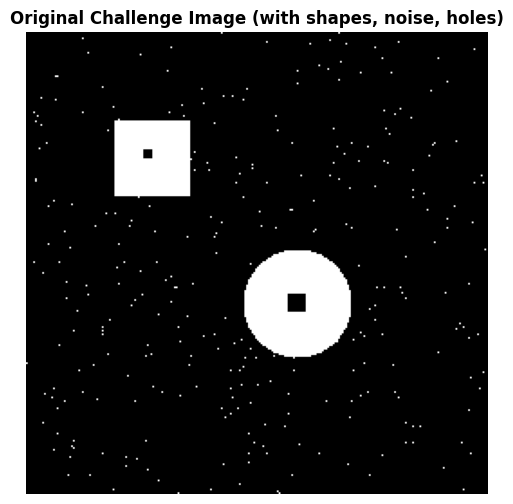

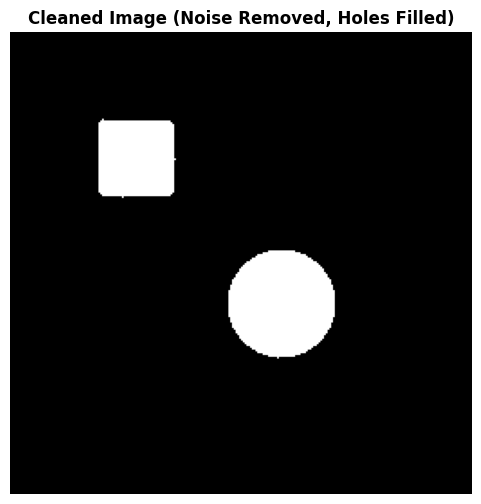

Found 2 potential objects.


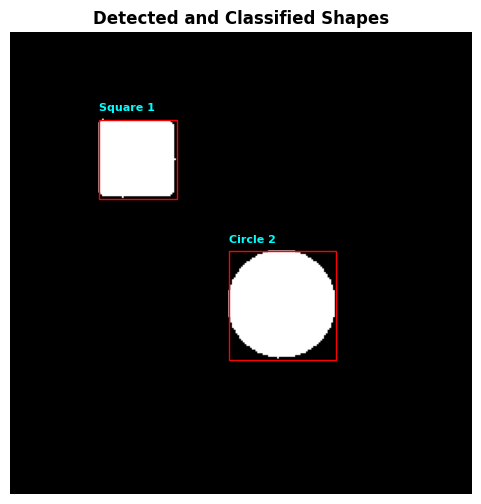


--- Classification Summary ---
Total Circles Detected: 1
Total Squares Detected: 1
------------------------------


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# STUDENT CHALLENGE: THE SHAPE DETECTOR (Work below this line)
# ════════════════════════════════════════════════════════════════════════════

# Import necessary libraries for this challenge (making this cell self-contained)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import morphology, measure
from skimage.draw import disk, rectangle_perimeter
from scipy import ndimage

# Step 1: Generate a Test Image with shapes, noise, and holes

H, W = 256, 256
test_challenge_img = np.zeros((H, W), dtype=np.uint8)

# Add a square
rr_sq, cc_sq = rectangle_perimeter((50, 50), extent=(40, 40), shape=(H,W))
test_challenge_img[rr_sq, cc_sq] = 1
# Fill the square (simple approach)
test_challenge_img[50:90, 50:90] = 1

# Add a circle
rr_circ, cc_circ = disk((150, 150), 30, shape=(H,W))
test_challenge_img[rr_circ, cc_circ] = 1

# Add some noise
noise_mask = np.random.rand(H, W) < 0.005 # 0.5% noise
test_challenge_img[noise_mask] = 1

# Add some holes to shapes
test_challenge_img[65:70, 65:70] = 0 # Hole in square
test_challenge_img[145:155, 145:155] = 0 # Hole in circle


plt.figure(figsize=(6, 6))
plt.imshow(test_challenge_img, cmap='gray')
plt.title("Original Challenge Image (with shapes, noise, holes)", fontweight='bold')
plt.axis('off')
plt.show()


# Step 2: Pre-process the image (thresholding, morphology)

# Convert to float for noise addition if desired, then back to uint8 binary
# Current image is already binary, so direct morphology

se_disk_small = morphology.disk(2) # Small SE for opening
se_disk_large = morphology.disk(5) # Larger SE for closing

cleaned_img = morphology.binary_opening(test_challenge_img, se_disk_small)
cleaned_img = morphology.binary_closing(cleaned_img, se_disk_large)
cleaned_img = ndimage.binary_fill_holes(cleaned_img).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(cleaned_img, cmap='gray')
plt.title("Cleaned Image (Noise Removed, Holes Filled)", fontweight='bold')
plt.axis('off')
plt.show()


# Step 3: Detect & Label shapes

labeled_img, num_labels = measure.label(cleaned_img, connectivity=2, return_num=True)
properties = measure.regionprops(labeled_img)

print(f"Found {num_labels} potential objects.")

# Step 4 & 5: Analyze, Classify & Visualize

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cleaned_img, cmap='gray')
ax.set_title("Detected and Classified Shapes", fontweight='bold')
ax.axis('off')

circle_count = 0
square_count = 0

for i, prop in enumerate(properties):
    if prop.area < 100: # Filter out very small artifacts
        continue

    # Circularity metric: 4 * pi * Area / Perimeter^2
    # For a perfect circle, circularity is 1. For a square, it's ~0.785
    perimeter = prop.perimeter
    area = prop.area
    circularity = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0

    label_text = "Unknown"
    # Adjusting thresholds for better classification
    if circularity > 0.90: # Closer to 1 for circles
        label_text = "Circle"
        circle_count += 1
    elif circularity > 0.60 and circularity < 0.85: # Wider range for squares (around 0.785)
        label_text = "Square"
        square_count += 1

    # Draw bounding box and label
    min_r, min_c, max_r, max_c = prop.bbox
    bbox = patches.Rectangle((min_c, min_r), max_c - min_c, max_r - min_r,
                             fill=False, edgecolor='red', linewidth=1)
    ax.add_patch(bbox)
    ax.text(min_c, min_r - 5, f"{label_text} {i+1}", color='cyan', fontsize=8, fontweight='bold')

plt.show()

print(f"\n--- Classification Summary ---")
print(f"Total Circles Detected: {circle_count}")
print(f"Total Squares Detected: {square_count}")
print(f"------------------------------")

---
## 🏁 End of Computer Vision Unit 1 Notebook

### Topics Covered ✅
- [x] Digital Image Representation (matrix, pixels, values)
- [x] Sampling (spatial resolution) & Quantization (bit depth)
- [x] Types of Images: Binary, Grayscale, RGB, HSV
- [x] Pixel Neighbors: 4-connectivity, 8-connectivity
- [x] Distance Measures: Euclidean, City-block, Chessboard
- [x] Digital Video: frames, fps, bandwidth calculation
- [x] Image Histogram: computation, equalization, CDF
- [x] Arithmetic Operations: add, subtract, multiply, blend
- [x] Geometric Transformations: translate, rotate, scale, flip, shear, affine
- [x] Binary Processing: thresholding (global, Otsu, adaptive), region props
- [x] Binary Morphology: erosion, dilation, opening, closing, gradient, skeleton

---
> 📌 **Notebook by:** *Computer Vision Unit 1 – 2026 Edition*  
> 📌 **Libraries:** numpy · matplotlib · opencv · scikit-image · scipy · imageio
